# Breast Cancer Wisconsin: Exploratory Data Analysis

**Goal:** Understand the structure of the Breast Cancer Wisconsin (Diagnostic) dataset and identify which tumor measurements best separate **malignant** from **benign** cases, then validate those findings with a simple baseline classifier.

**Dataset:** 569 samples, 30 numeric features computed from digitized images of fine-needle aspirates of breast masses (available via `sklearn.datasets.load_breast_cancer`).

**Contents**
1. Setup and data loading
2. Data quality checks
3. Target distribution
4. Feature distributions
5. Feature relationships
6. Baseline model
7. Key takeaways

## 1. Setup and data loading

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42
IMG_DIR = Path("images")
IMG_DIR.mkdir(exist_ok=True)

# Colour and label mapping used throughout (in the dataset, 0 = malignant, 1 = benign)
CLASS_NAMES = {0: "Malignant", 1: "Benign"}
PALETTE = {"Malignant": "#d62728", "Benign": "#2ca02c"}

In [2]:
bc = load_breast_cancer()
data = pd.DataFrame(bc.data, columns=bc.feature_names)
data["target"] = bc.target
data["diagnosis"] = data["target"].map(CLASS_NAMES)

data.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


## 2. Data quality checks

In [3]:
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
print(f"Missing values: {int(data.isnull().sum().sum())}")
print(f"Duplicate rows: {int(data.duplicated().sum())}")
data.info()

Rows: 569, Columns: 32
Missing values: 0
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non

In [4]:
data.drop(columns="diagnosis").describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
mean radius,569.0,14.127,3.524,6.981,11.700,13.370,15.780,28.110
mean texture,569.0,19.290,4.301,9.710,16.170,18.840,21.800,39.280
mean perimeter,569.0,91.969,24.299,43.790,75.170,86.240,104.100,188.500
mean area,569.0,654.889,351.914,143.500,420.300,551.100,782.700,2501.000
mean smoothness,569.0,0.096,0.014,0.053,0.086,0.096,0.105,0.163
mean compactness,569.0,0.104,0.053,0.019,0.065,0.093,0.130,0.345
mean concavity,569.0,0.089,0.080,0.000,0.030,0.062,0.131,0.427
mean concave points,569.0,0.049,0.039,0.000,0.020,0.034,0.074,0.201
mean symmetry,569.0,0.181,0.027,0.106,0.162,0.179,0.196,0.304
mean fractal dimension,569.0,0.063,0.007,0.050,0.058,0.062,0.066,0.097


The dataset is clean: no missing values or duplicates, and all features are numeric. The features span very different scales (e.g. `mean area` is in the hundreds, `mean smoothness` is below 1), so scaling will matter for distance- or gradient-based models.

## 3. Target distribution

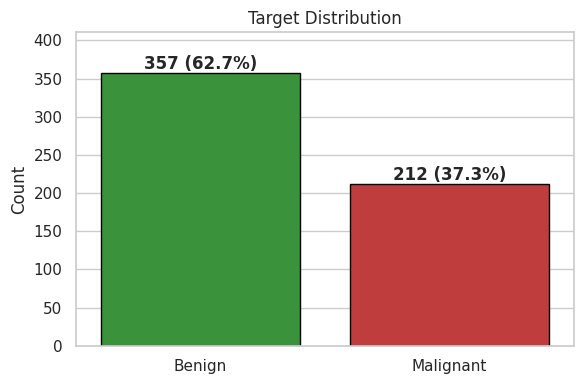

In [5]:
counts = data["diagnosis"].value_counts()
pct = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, hue=counts.index,
            palette=PALETTE, edgecolor="black", legend=False, ax=ax)
for i, (n, p) in enumerate(zip(counts.values, pct.values)):
    ax.text(i, n + 5, f"{n} ({p:.1f}%)", ha="center", fontweight="bold")
ax.set(title="Target Distribution", xlabel="", ylabel="Count", ylim=(0, counts.max() * 1.15))
plt.tight_layout()
plt.savefig(IMG_DIR / "target_distribution.png", dpi=150)
plt.show()

The classes are moderately imbalanced (about 63% benign vs 37% malignant). That is not severe, but it means accuracy alone can be misleading, so the baseline model reports precision and recall per class.

## 4. Feature distributions

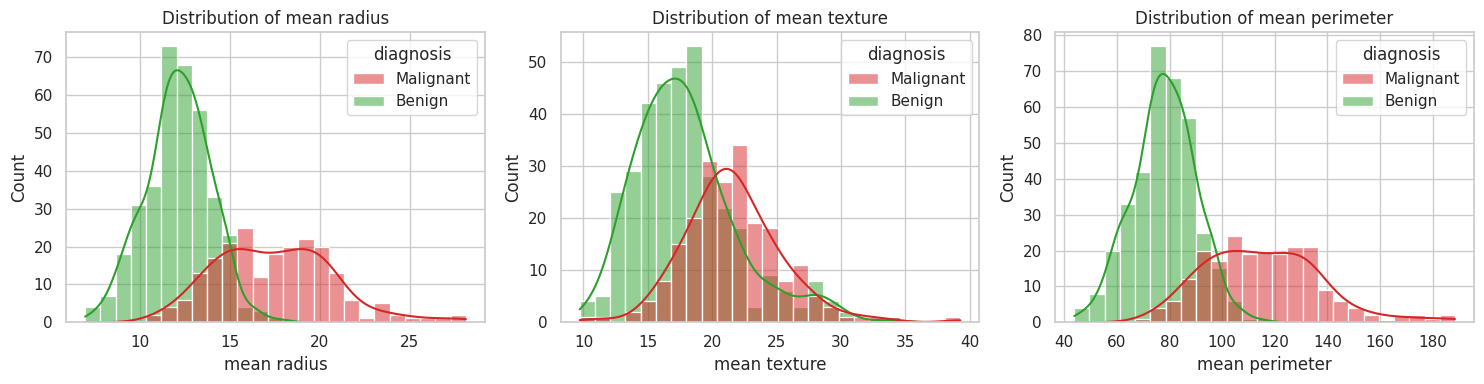

In [6]:
features = ["mean radius", "mean texture", "mean perimeter"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, features):
    sns.histplot(data=data, x=f, hue="diagnosis", palette=PALETTE,
                 bins=25, kde=True, alpha=0.5, ax=ax)
    ax.set_title(f"Distribution of {f}")
plt.tight_layout()
plt.savefig(IMG_DIR / "feature_distributions.png", dpi=150)
plt.show()

`mean radius` and `mean perimeter` show clear separation: malignant tumors skew larger. `mean texture` overlaps heavily, so it is a weaker discriminator on its own.

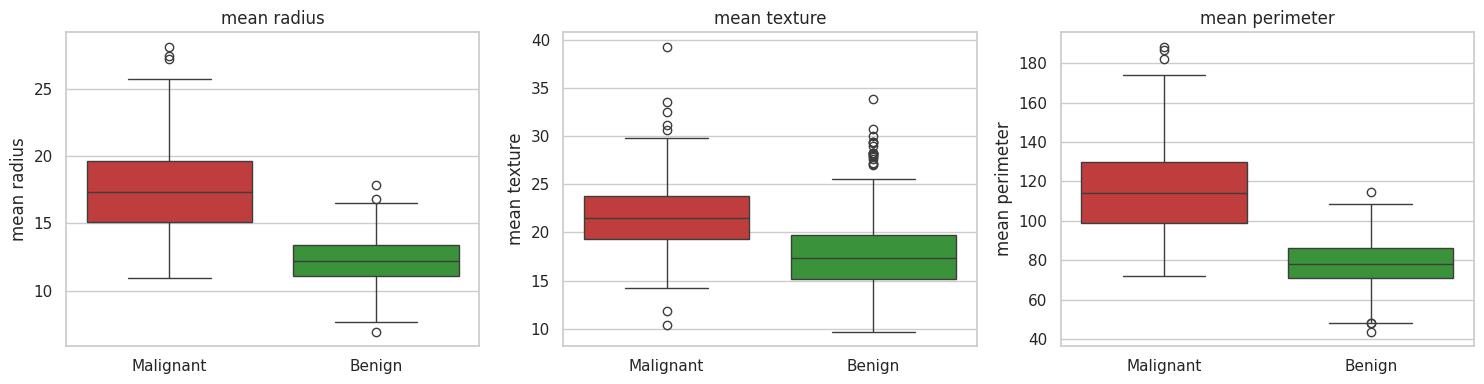

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, f in zip(axes, features):
    sns.boxplot(data=data, x="diagnosis", y=f, hue="diagnosis",
                palette=PALETTE, order=["Malignant", "Benign"], legend=False, ax=ax)
    ax.set(title=f, xlabel="")
plt.tight_layout()
plt.show()

## 5. Feature relationships

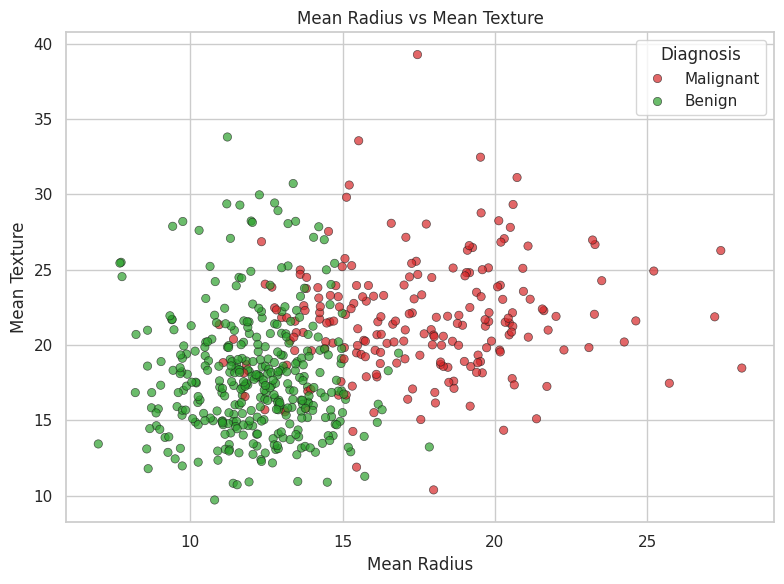

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=data, x="mean radius", y="mean texture", hue="diagnosis",
                palette=PALETTE, alpha=0.7, edgecolor="k", ax=ax)
ax.set(title="Mean Radius vs Mean Texture", xlabel="Mean Radius", ylabel="Mean Texture")
ax.legend(title="Diagnosis")
plt.tight_layout()
plt.savefig(IMG_DIR / "radius_vs_texture.png", dpi=150)
plt.show()

The two classes are largely separable along the radius axis, with some overlap in the middle range.

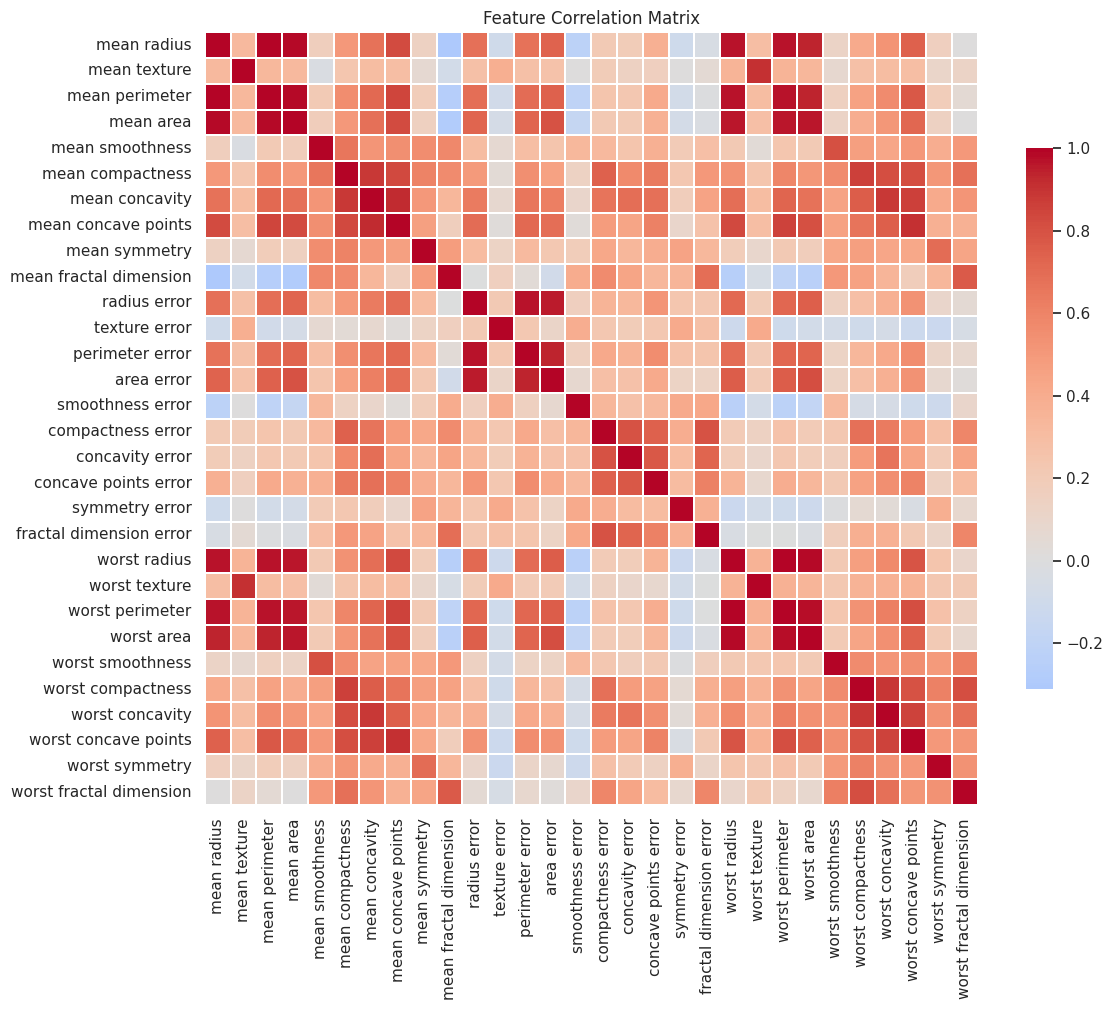

In [9]:
corr = data[bc.feature_names].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True,
            linewidths=0.2, cbar_kws={"shrink": 0.7}, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.savefig(IMG_DIR / "correlation_heatmap.png", dpi=150)
plt.show()

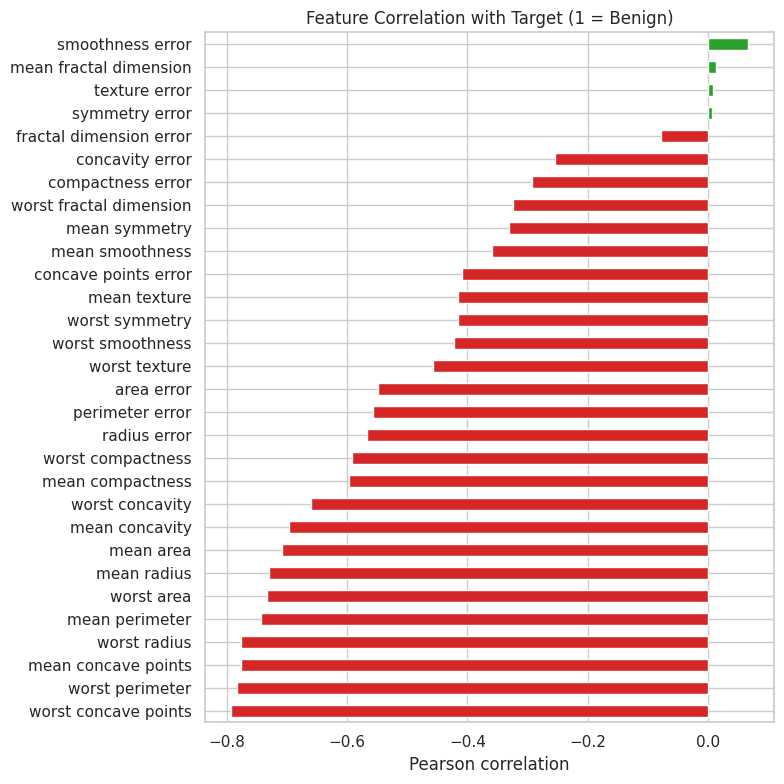

worst concave points    0.794
worst perimeter         0.783
mean concave points     0.777
worst radius            0.776
mean perimeter          0.743
dtype: float64

In [10]:
# Which features correlate most strongly with the diagnosis?
# Target: 0 = malignant, so negative correlation means "higher value -> more likely malignant"
target_corr = data[bc.feature_names].corrwith(data["target"]).sort_values()

fig, ax = plt.subplots(figsize=(8, 8))
target_corr.plot.barh(color=np.where(target_corr < 0, PALETTE["Malignant"], PALETTE["Benign"]), ax=ax)
ax.set(title="Feature Correlation with Target (1 = Benign)", xlabel="Pearson correlation")
plt.tight_layout()
plt.savefig(IMG_DIR / "target_correlation.png", dpi=150)
plt.show()

target_corr.abs().sort_values(ascending=False).head(5).round(3)

Many features are highly correlated with each other (radius, perimeter and area are geometrically linked), which signals **multicollinearity**. Size and concavity-related features (`worst concave points`, `worst perimeter`, `worst radius`) are the strongest predictors of diagnosis.

## 6. Baseline model

A scaled logistic regression gives a quick sanity check that the patterns found above are genuinely predictive. A stratified split preserves the class ratio.

In [11]:
X = data[bc.feature_names]
y = data["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Malignant", "Benign"]))

              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



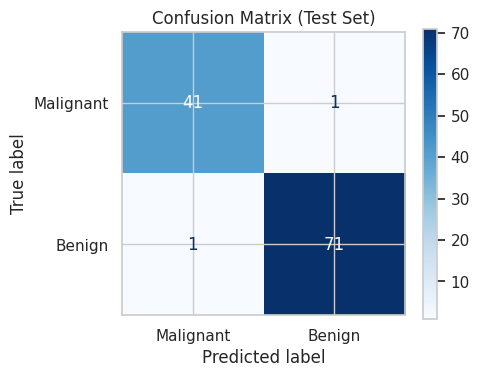

In [12]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, display_labels=["Malignant", "Benign"], cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig(IMG_DIR / "confusion_matrix.png", dpi=150)
plt.show()

## 7. Key takeaways

- **Clean data:** no missing values or duplicates; all 30 features are numeric.
- **Mild class imbalance:** ~63% benign, ~37% malignant.
- **Size matters:** malignant tumors tend to have larger radius, perimeter and area; texture alone is a weak separator.
- **Multicollinearity:** many features are strongly correlated, so dimensionality reduction (PCA) or regularization would be sensible next steps.
- **Strong baseline:** a simple scaled logistic regression performs well, confirming the features carry strong signal.

**Possible extensions:** cross-validation, hyperparameter tuning, tree-based models (Random Forest, Gradient Boosting), feature importance / SHAP, and PCA visualization.

> **Note:** This is an educational analysis on a public dataset and is not intended for clinical use.